In [216]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [217]:
df= pd.read_csv("Bengaluru_House_Data.csv")

In [218]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [219]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns)
print("Dataset Information:")
df.info()

Shape: (13320, 9)
Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [220]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [221]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [222]:
df["size"].head(10)

0        2 BHK
1    4 Bedroom
2        3 BHK
3        3 BHK
4        2 BHK
5        2 BHK
6        4 BHK
7        4 BHK
8        3 BHK
9    6 Bedroom
Name: size, dtype: str

In [223]:
df["size"].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [224]:
df["size"] = df["size"].str.strip()
df["availability"] = df["availability"].str.strip()
df["location"] = df["location"].str.strip()
df["society"] = df["society"].str.strip()
df["total_sqft"] = df["total_sqft"].str.strip()
df["area_type"] = df["area_type"].str.strip()

In [225]:
df["room_count"] = df["size"].str.split().str[0].astype(float)

In [226]:
df["property_type"] = df["size"].str.split().str[1]

In [227]:
print(df["room_count"].isnull().sum())
print(df["property_type"].isnull().sum())
print(df["property_type"].value_counts(dropna=False))

16
16
property_type
BHK        10766
Bedroom     2525
NaN           16
RK            13
Name: count, dtype: int64


In [228]:
df["property_type"] = df["property_type"].fillna("Unknown")

In [229]:
df["room_count"] = df["room_count"].fillna(df["room_count"].median())

In [230]:
print(df["room_count"].isnull().sum())
print(df["property_type"].isnull().sum())

0
0


In [231]:
df["society"]

0         Coomee
1        Theanmp
2            NaN
3        Soiewre
4            NaN
          ...   
13315    ArsiaEx
13316        NaN
13317    Mahla T
13318    SollyCl
13319        NaN
Name: society, Length: 13320, dtype: str

In [232]:
df["society"] = df["society"].fillna(
    df.groupby("location")["society"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
    )
)

In [233]:
print(df["society"].isnull().sum())

0


In [234]:
print(df.duplicated().sum())

550


In [235]:
df[df.duplicated()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,room_count,property_type
971,Super built-up Area,Ready To Move,Haralur Road,3 BHK,NRowse,1464,3.0,2.0,56.0,3.0,BHK
1115,Super built-up Area,Ready To Move,Haralur Road,2 BHK,SNnia E,1027,2.0,2.0,44.0,2.0,BHK
1143,Super built-up Area,Ready To Move,Vittasandra,2 BHK,Prlla C,1246,2.0,1.0,64.5,2.0,BHK
1290,Super built-up Area,Ready To Move,Haralur Road,2 BHK,SNnia E,1194,2.0,2.0,47.0,2.0,BHK
1394,Super built-up Area,Ready To Move,Haralur Road,2 BHK,SNnia E,1027,2.0,2.0,44.0,2.0,BHK
...,...,...,...,...,...,...,...,...,...,...,...
13285,Super built-up Area,Ready To Move,VHBCS Layout,2 BHK,OlarkLa,1353,2.0,2.0,110.0,2.0,BHK
13299,Super built-up Area,18-Dec,Whitefield,4 BHK,Prtates,2830 - 2882,5.0,0.0,154.5,4.0,BHK
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,Vaharvi,1500,9.0,2.0,250.0,7.0,Bedroom
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345,2.0,1.0,57.0,3.0,BHK


In [236]:
df["balcony"].head(10)

0    1.0
1    3.0
2    3.0
3    1.0
4    1.0
5    1.0
6    NaN
7    NaN
8    1.0
9    NaN
Name: balcony, dtype: float64

In [237]:
print(df["balcony"].isnull().sum())

609


In [238]:
df["balcony"].value_counts()

balcony
2.0    5113
1.0    4897
3.0    1672
0.0    1029
Name: count, dtype: int64

In [239]:
df["balcony"] = df["balcony"].fillna(df["balcony"].mode()[0])
print(df["balcony"].isnull().sum())

0


In [240]:
print(df["bath"].isnull().sum())

73


In [241]:
print(df["bath"].value_counts(dropna=False))

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
NaN       73
8.0       64
9.0       43
10.0      13
12.0       7
11.0       3
13.0       3
16.0       2
14.0       1
27.0       1
40.0       1
15.0       1
18.0       1
Name: count, dtype: int64


In [242]:
print(df["bath"].describe())

count    13247.000000
mean         2.692610
std          1.341458
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         40.000000
Name: bath, dtype: float64


In [243]:
bath_median = df.groupby("room_count")["bath"].transform("median")
df["bath"] = df["bath"].fillna(df["bath"].median())

In [244]:
print(df["bath"].isnull().sum())

0


In [245]:
df["bath"].value_counts(dropna=False)

bath
2.0     6981
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
11.0       3
13.0       3
16.0       2
14.0       1
27.0       1
40.0       1
15.0       1
18.0       1
Name: count, dtype: int64

In [246]:
print(df["location"].isnull().sum())

1


In [247]:
print(df["location"].nunique())

1294


In [248]:
print(df["location"].value_counts(dropna=False))

location
Whitefield                                         541
Sarjapur  Road                                     399
Electronic City                                    304
Kanakpura Road                                     273
Thanisandra                                        237
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1295, dtype: int64


In [249]:
df["location"] = df["location"].fillna("Unknown")

In [250]:
df.loc[df["location"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,room_count,property_type


In [251]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area_type      13320 non-null  str    
 1   availability   13320 non-null  str    
 2   location       13320 non-null  str    
 3   size           13304 non-null  str    
 4   society        13320 non-null  str    
 5   total_sqft     13320 non-null  str    
 6   bath           13320 non-null  float64
 7   balcony        13320 non-null  float64
 8   price          13320 non-null  float64
 9   room_count     13320 non-null  float64
 10  property_type  13320 non-null  object 
dtypes: float64(4), object(1), str(6)
memory usage: 1.1+ MB


In [252]:
print(df["area_type"].isnull().sum())
print(df["area_type"].value_counts(dropna=False))

0
area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64


In [253]:
print(df["availability"].isnull().sum())
print(df["availability"].value_counts().head(20))

0
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
19-Dec             185
18-Jul             143
18-Mar             131
18-Jun              99
20-Dec              98
21-Dec              93
19-Mar              88
18-Feb              62
18-Nov              47
18-Jan              43
18-Sep              41
19-Jun              40
18-Oct              39
19-Jan              39
19-Jul              36
Name: count, dtype: int64


In [254]:
print("Unique values:", df["availability"].nunique())

Unique values: 81


In [255]:
df["total_sqft"].value_counts()

total_sqft
1200           843
1100           221
1500           205
2400           196
600            180
              ... 
1020 - 1130      1
2758             1
1133 - 1384      1
774              1
4689             1
Name: count, Length: 2117, dtype: int64

In [256]:
df["total_sqft"].value_counts().head(20)

total_sqft
1200    843
1100    221
1500    205
2400    196
600     180
1000    172
1350    133
1050    123
1300    117
1250    114
900     112
1400    108
1800    104
1600    101
1150    101
1140     91
2000     83
1450     70
1650     69
800      67
Name: count, dtype: int64

In [257]:
df["total_sqft"].value_counts().tail(20)

total_sqft
1200 - 1470    1
7150           1
1369           1
5665.84        1
2920           1
6688           1
1331.95        1
2872           1
1648           1
1379           1
3124           1
9200           1
613            1
250            1
2395           1
1020 - 1130    1
2758           1
1133 - 1384    1
774            1
4689           1
Name: count, dtype: int64

In [258]:
print(df["total_sqft"].dtype)
print(df["total_sqft"].nunique())

str
2117


In [259]:
df[df["total_sqft"].str.contains("-", na=False)]["total_sqft"].head(20)

30     2100 - 2850
56     3010 - 3410
81     2957 - 3450
122    3067 - 8156
137    1042 - 1105
165    1145 - 1340
188    1015 - 1540
224    1520 - 1740
549    1195 - 1440
579    1200 - 2400
661    1120 - 1145
669    4400 - 6640
672    3090 - 5002
702    4400 - 6800
772    1160 - 1195
801    4000 - 5249
850    1115 - 1130
886      520 - 645
927    1000 - 1285
941    3606 - 5091
Name: total_sqft, dtype: str

In [260]:
def clean_total_sqft(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    if "perch" in x.lower():
        num_str = x.lower().replace("perch", "").strip()
        return pd.to_numeric(num_str) * 272.25
    if "sq. yards" in x.lower():
        num_str = x.lower().replace("sq. yards", "").strip()
        return pd.to_numeric(num_str) * 9.0
    if "acre" in x.lower():
        num_str = x.lower().replace("acres", "").replace("acre", "").strip()
        return pd.to_numeric(num_str) * 43560.0
    if "sq. meter" in x.lower():
        num_str = x.lower().replace("sq. meter", "").strip()
        return pd.to_numeric(num_str) * 10.7639
    if "cent" in x.lower():
        num_str = x.lower().replace("cents", "").replace("cent", "").strip()
        return pd.to_numeric(num_str) * 435.6
    if "ground" in x.lower():
        num_str = x.lower().replace("grounds", "").replace("ground", "").strip()
        return pd.to_numeric(num_str) * 2400.0
    if "guntha" in x.lower():
        num_str = x.lower().replace("guntha", "").strip()
        return pd.to_numeric(num_str) * 1089.0
    if "-" in x:
        parts = x.split("-")
        v1 = pd.to_numeric(parts[0].strip())
        v2 = pd.to_numeric(parts[1].strip())
        return (v1 + v2) / 2.0
    return pd.to_numeric(x)

In [261]:
df["total_sqft"] = df["total_sqft"].apply(clean_total_sqft)

In [262]:
df["total_sqft"].value_counts()

total_sqft
1200.0    843
1100.0    221
1500.0    206
2400.0    197
600.0     180
         ... 
2395.0      1
2758.0      1
1258.5      1
774.0       1
4689.0      1
Name: count, Length: 2034, dtype: int64

In [263]:
df.isna().sum()

area_type         0
availability      0
location          0
size             16
society           0
total_sqft        0
bath              0
balcony           0
price             0
room_count        0
property_type     0
dtype: int64

In [264]:
df.loc[df["size"].isna()]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,room_count,property_type
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1800.0,2.0,2.0,34.185,3.0,Unknown
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,3817.0,2.0,2.0,124.000,3.0,Unknown
2264,Plot Area,Immediate Possession,Banashankari,NaN,Bregae,2400.0,2.0,2.0,460.000,3.0,Unknown
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1800.0,2.0,2.0,28.785,3.0,Unknown
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1950.0,2.0,2.0,46.800,3.0,Unknown
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,3752.5,2.0,2.0,177.115,3.0,Unknown
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324.0,2.0,2.0,26.730,3.0,Unknown
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500.0,2.0,2.0,25.490,3.0,Unknown
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,1730.0,2.0,2.0,28.545,3.0,Unknown
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,HMonymp,5000.0,2.0,2.0,400.000,3.0,Unknown


In [265]:
df = df[df["size"].notna()]

In [266]:
print(df["size"].isna().sum())

0


In [267]:
print("Shape:", df.shape)
print("Missing Values:")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Data Types:")
print(df.dtypes)

Shape: (13304, 11)
Missing Values:
area_type        0
availability     0
location         0
size             0
society          0
total_sqft       0
bath             0
balcony          0
price            0
room_count       0
property_type    0
dtype: int64
Duplicates: 551
Data Types:
area_type            str
availability         str
location             str
size                 str
society              str
total_sqft       float64
bath             float64
balcony          float64
price            float64
room_count       float64
property_type     object
dtype: object


In [268]:
df[["size", "room_count", "property_type"]].head(10)

,size,room_count,property_type
0,2 BHK,2.0,BHK
1,4 Bedroom,4.0,Bedroom
2,3 BHK,3.0,BHK
3,3 BHK,3.0,BHK
4,2 BHK,2.0,BHK
5,2 BHK,2.0,BHK
6,4 BHK,4.0,BHK
7,4 BHK,4.0,BHK
8,3 BHK,3.0,BHK
9,6 Bedroom,6.0,Bedroom


In [269]:
#df.drop("size", axis=1, inplace=True)

In [270]:
print("Location missing:", df["location"].isnull().sum())
print("Society missing:", df["society"].isnull().sum())

Location missing: 0
Society missing: 0


In [271]:
print("Missing values:", df["price"].isnull().sum())
print("Data type:", df["price"].dtype)
print(df["price"].describe())

Missing values: 0
Data type: float64
count    13304.000000
mean       112.582035
std        148.988398
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64


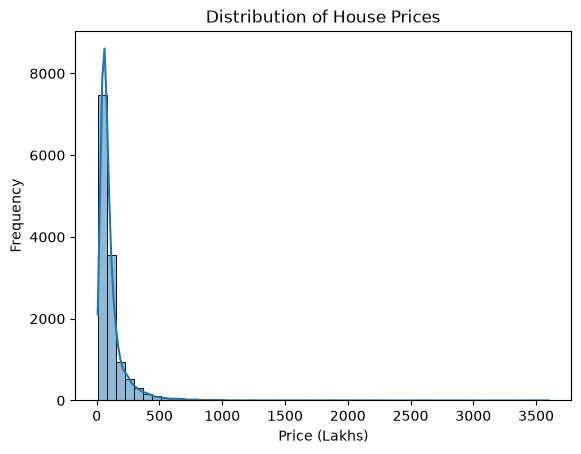

In [272]:
sns.histplot(df["price"], bins=50, kde=True)
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

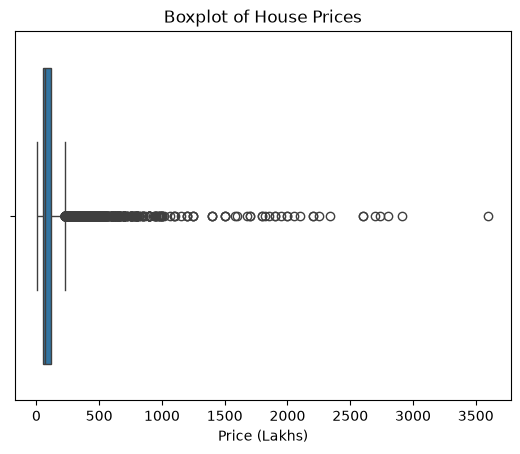

In [273]:
sns.boxplot(x=df["price"])
plt.xlabel("Price (Lakhs)")
plt.title("Boxplot of House Prices")
plt.show()

In [274]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 50.0
Q3: 120.0
IQR: 70.0
Lower Limit: -55.0
Upper Limit: 225.0


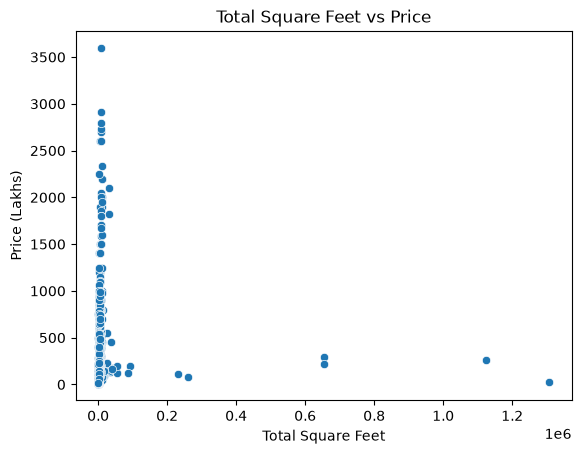

In [275]:
sns.scatterplot(
    data=df,
    x="total_sqft",
    y="price"
)
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")
plt.title("Total Square Feet vs Price")
plt.show()

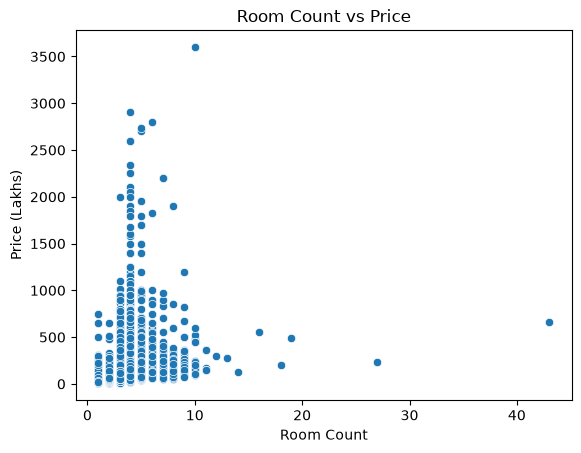

In [276]:
sns.scatterplot(
    data=df,
    x="room_count",
    y="price"
)
plt.xlabel("Room Count")
plt.ylabel("Price (Lakhs)")
plt.title("Room Count vs Price")
plt.show()

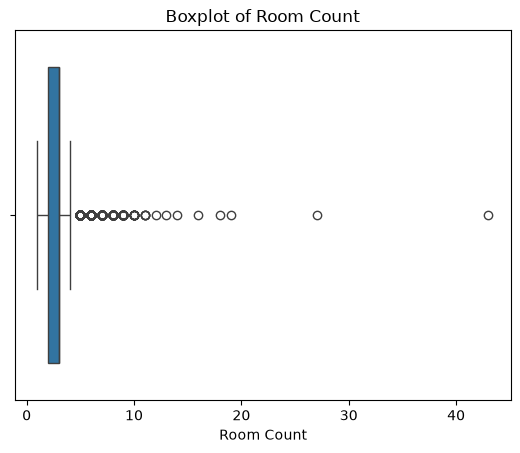

In [277]:
sns.boxplot(x=df["room_count"])
plt.xlabel("Room Count")
plt.title("Boxplot of Room Count")
plt.show()

In [278]:
print(df["room_count"].describe())
print(df["room_count"].value_counts().sort_index())

count    13304.000000
mean         2.803743
std          1.294974
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         43.000000
Name: room_count, dtype: float64
room_count
1.0      656
2.0     5528
3.0     4857
4.0     1417
5.0      356
6.0      221
7.0      100
8.0       89
9.0       54
10.0      14
11.0       4
12.0       1
13.0       1
14.0       1
16.0       1
18.0       1
19.0       1
27.0       1
43.0       1
Name: count, dtype: int64


In [279]:
df[df["room_count"] >= 10][
    ["room_count", "property_type", "total_sqft", "bath", "price", "location"]
].sort_values("room_count", ascending=False)

,room_count,property_type,total_sqft,bath,price,location
4684,43.0,Bedroom,2400.0,40.0,660.0,Munnekollal
1718,27.0,BHK,8000.0,27.0,230.0,2Electronic City Phase II
3379,19.0,BHK,2000.0,16.0,490.0,1Hanuman Nagar
11559,18.0,Bedroom,1200.0,18.0,200.0,1Kasavanhalli
3609,16.0,BHK,10000.0,16.0,550.0,Koramangala Industrial Layout
4916,14.0,BHK,1250.0,15.0,125.0,1Channasandra
9935,13.0,BHK,5425.0,13.0,275.0,1Hoysalanagar
6533,12.0,Bedroom,2232.0,6.0,300.0,Mysore Road
1768,11.0,Bedroom,1200.0,11.0,170.0,1 Ramamurthy Nagar
459,11.0,BHK,5000.0,9.0,360.0,1 Giri Nagar


In [280]:
df["sqft_per_room"] = df["total_sqft"] / df["room_count"]
df["sqft_per_room"].describe()

count     13304.000000
mean        701.787323
std        6563.099419
min           0.250000
25%         473.333333
50%         552.500000
75%         625.000000
max      653400.000000
Name: sqft_per_room, dtype: float64

In [281]:
df[df["room_count"] >= 10][
    ["room_count", "total_sqft", "sqft_per_room", "bath", "price", "location"]
].sort_values("room_count", ascending=False)

,room_count,total_sqft,sqft_per_room,bath,price,location
4684,43.0,2400.0,55.813953,40.0,660.0,Munnekollal
1718,27.0,8000.0,296.296296,27.0,230.0,2Electronic City Phase II
3379,19.0,2000.0,105.263158,16.0,490.0,1Hanuman Nagar
11559,18.0,1200.0,66.666667,18.0,200.0,1Kasavanhalli
3609,16.0,10000.0,625.000000,16.0,550.0,Koramangala Industrial Layout
4916,14.0,1250.0,89.285714,15.0,125.0,1Channasandra
9935,13.0,5425.0,417.307692,13.0,275.0,1Hoysalanagar
6533,12.0,2232.0,186.000000,6.0,300.0,Mysore Road
1768,11.0,1200.0,109.090909,11.0,170.0,1 Ramamurthy Nagar
459,11.0,5000.0,454.545455,9.0,360.0,1 Giri Nagar


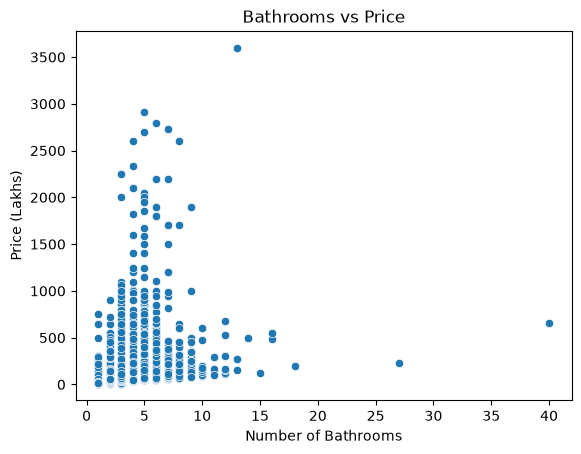

In [282]:
sns.scatterplot(
    data=df,
    x="bath",
    y="price"
)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bathrooms vs Price")
plt.show()

In [283]:
print(df["bath"].describe())
print(df["bath"].value_counts().sort_index())

count    13304.000000
mean         2.689642
std          1.339345
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         40.000000
Name: bath, dtype: float64
bath
1.0      788
2.0     6965
3.0     3286
4.0     1226
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
11.0       3
12.0       7
13.0       3
14.0       1
15.0       1
16.0       2
18.0       1
27.0       1
40.0       1
Name: count, dtype: int64


In [284]:
df[df["bath"] >= 10][
    ["room_count", "bath", "total_sqft", "price", "location"]
].sort_values("bath", ascending=False)

,room_count,bath,total_sqft,price,location
4684,43.0,40.0,2400.0,660.0,Munnekollal
1718,27.0,27.0,8000.0,230.0,2Electronic City Phase II
11559,18.0,18.0,1200.0,200.0,1Kasavanhalli
3609,16.0,16.0,10000.0,550.0,Koramangala Industrial Layout
3379,19.0,16.0,2000.0,490.0,1Hanuman Nagar
4916,14.0,15.0,1250.0,125.0,1Channasandra
1078,9.0,14.0,3300.0,500.0,BTM 1st Stage
13067,10.0,13.0,7150.0,3600.0,Defence Colony
9935,13.0,13.0,5425.0,275.0,1Hoysalanagar
10695,9.0,13.0,1200.0,150.0,Electronic City


In [285]:
print(df["balcony"].value_counts().sort_index())

balcony
0.0    1029
1.0    4897
2.0    5706
3.0    1672
Name: count, dtype: int64


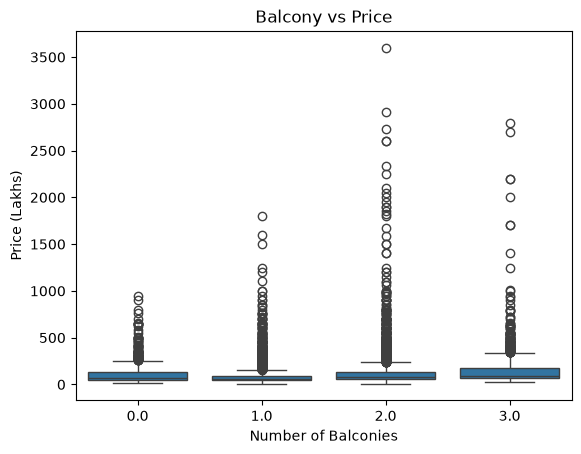

In [286]:
sns.boxplot(data=df, x="balcony", y="price")
plt.xlabel("Number of Balconies")
plt.ylabel("Price (Lakhs)")
plt.title("Balcony vs Price")
plt.show()

In [287]:
print(df["area_type"].value_counts())

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2009
Carpet  Area              87
Name: count, dtype: int64


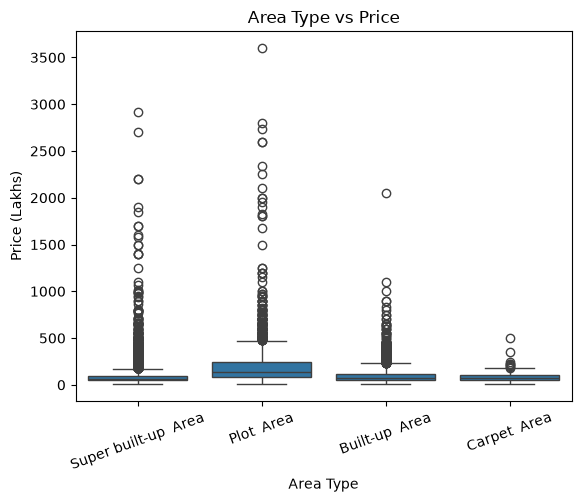

In [288]:
sns.boxplot(data=df, x="area_type", y="price")
plt.xlabel("Area Type")
plt.ylabel("Price (Lakhs)")
plt.title("Area Type vs Price")
plt.xticks(rotation=20)
plt.show()

In [289]:
print(df["property_type"].value_counts(dropna=False))

property_type
BHK        10766
Bedroom     2525
RK            13
Name: count, dtype: int64


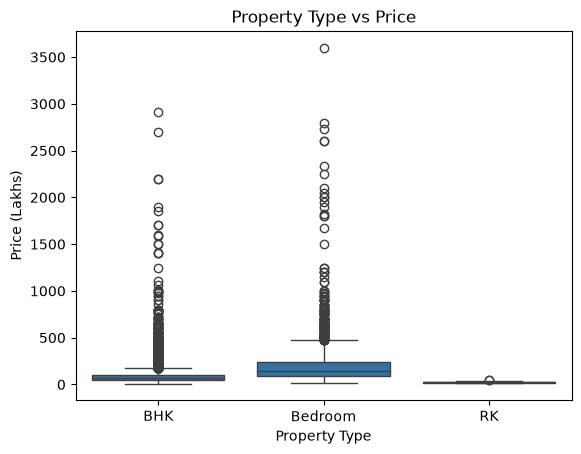

In [290]:
sns.boxplot(data=df, x="property_type", y="price")
plt.xlabel("Property Type")
plt.ylabel("Price (Lakhs)")
plt.title("Property Type vs Price")
plt.show()

In [291]:
print(df["availability"].value_counts().head(20))
print("Unique values:", df["availability"].nunique())

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
19-Dec             185
18-Jul             143
18-Mar             131
18-Jun              99
20-Dec              98
21-Dec              93
19-Mar              88
18-Feb              62
18-Nov              47
18-Jan              43
18-Sep              41
19-Jun              40
18-Oct              39
19-Jan              39
19-Jul              36
Name: count, dtype: int64
Unique values: 80


In [292]:
def clean_availability(x):
    if x == "Ready To Move":
        return "Ready To Move"
    elif x == "Immediate Possession":
        return "Immediate Possession"
    else:
        return "Future Possession"

df["availability_status"] = df["availability"].apply(clean_availability)

In [293]:
print(df["availability_status"].value_counts())

availability_status
Ready To Move        10581
Future Possession     2723
Name: count, dtype: int64


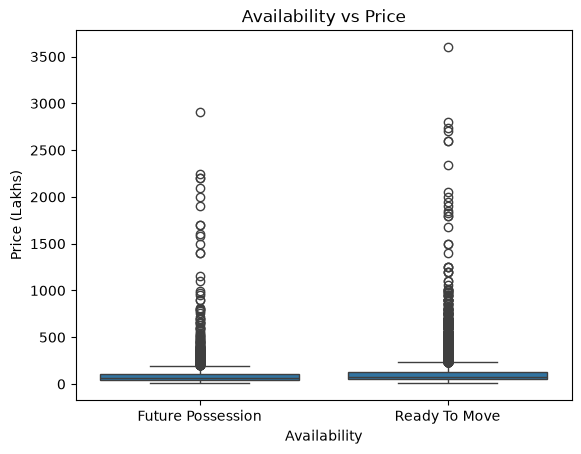

In [294]:
sns.boxplot(data=df,x="availability_status",y="price")
plt.xlabel("Availability")
plt.ylabel("Price (Lakhs)")
plt.title("Availability vs Price")
plt.show()

In [295]:
print("Unique locations:", df["location"].nunique())
print(df["location"].value_counts().head(20))

Unique locations: 1294
location
Whitefield                  540
Sarjapur  Road              397
Electronic City             304
Kanakpura Road              273
Thanisandra                 237
Yelahanka                   212
Uttarahalli                 186
Hebbal                      177
Marathahalli                175
Raja Rajeshwari Nagar       171
Hennur Road                 152
Bannerghatta Road           152
7th Phase JP Nagar          149
Haralur Road                142
Electronic City Phase II    132
Rajaji Nagar                107
Chandapura                  100
Bellandur                    96
KR Puram                     91
Electronics City Phase 1     88
Name: count, dtype: int64


In [296]:
location_count = df["location"].value_counts()
print("Locations with <= 10 properties:",
      (location_count <= 10).sum())

Locations with <= 10 properties: 1053


In [297]:
print("Unique societies:", df["society"].nunique())
print(df["society"].value_counts().head(20))

Unique societies: 2677
society
Unknown    1410
Prtates     180
PrarePa     122
GMown E     122
GrrvaGr     116
Aklia R     109
Adeatlm     100
PueraRi      86
SNnia E      80
SNity S      80
Brnia G      73
Bhmesy       71
Sryalan      71
Dhalsh       67
Prensya      64
PhestOn      62
IBityin      61
SunceEs      60
Prtanha      60
Vaharvi      59
Name: count, dtype: int64


In [298]:
society_count = df["society"].value_counts()
print("Societies with <= 10 properties:",
      (society_count <= 10).sum())

Societies with <= 10 properties: 2427


In [299]:
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.columns)

Index(['total_sqft', 'bath', 'balcony', 'price', 'room_count',
       'sqft_per_room'],
      dtype='str')


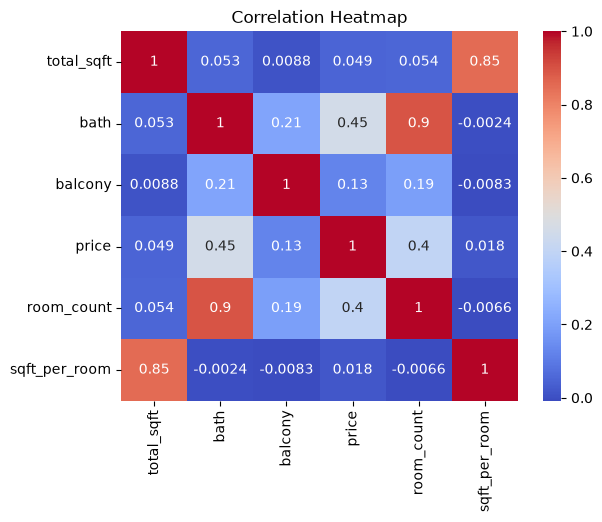

In [300]:
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [301]:
print(df.isnull().sum())

area_type              0
availability           0
location               0
size                   0
society                0
total_sqft             0
bath                   0
balcony                0
price                  0
room_count             0
property_type          0
sqft_per_room          0
availability_status    0
dtype: int64


In [302]:
duplicate_rows = df[df.duplicated(keep=False)]
print("Total duplicate rows:", len(duplicate_rows))
duplicate_rows.sort_values(
    by=["location", "total_sqft", "price"]
).head(30)

Total duplicate rows: 943


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,room_count,property_type,sqft_per_room,availability_status
2060,Super built-up Area,Ready To Move,2nd Phase Judicial Layout,2 BHK,Unknown,1150.0,2.0,1.0,40.25,2.0,BHK,575.000000,Ready To Move
13107,Super built-up Area,Ready To Move,2nd Phase Judicial Layout,2 BHK,Unknown,1150.0,2.0,1.0,40.25,2.0,BHK,575.000000,Ready To Move
7051,Super built-up Area,Ready To Move,2nd Phase Judicial Layout,3 BHK,Unknown,1350.0,2.0,2.0,47.25,3.0,BHK,450.000000,Ready To Move
8844,Super built-up Area,Ready To Move,2nd Phase Judicial Layout,3 BHK,Unknown,1350.0,2.0,2.0,47.25,3.0,BHK,450.000000,Ready To Move
12317,Super built-up Area,Ready To Move,2nd Phase Judicial Layout,3 BHK,Unknown,1350.0,2.0,2.0,47.25,3.0,BHK,450.000000,Ready To Move
3123,Plot Area,Ready To Move,2nd Stage Nagarbhavi,5 Bedroom,Unknown,1200.0,4.0,3.0,240.00,5.0,Bedroom,240.000000,Ready To Move
8008,Plot Area,Ready To Move,2nd Stage Nagarbhavi,5 Bedroom,Unknown,1200.0,4.0,3.0,240.00,5.0,Bedroom,240.000000,Ready To Move
9127,Plot Area,Ready To Move,2nd Stage Nagarbhavi,5 Bedroom,Unknown,1200.0,4.0,3.0,240.00,5.0,Bedroom,240.000000,Ready To Move
9830,Plot Area,Ready To Move,2nd Stage Nagarbhavi,5 Bedroom,Unknown,1200.0,4.0,2.0,240.00,5.0,Bedroom,240.000000,Ready To Move
10483,Plot Area,Ready To Move,2nd Stage Nagarbhavi,5 Bedroom,Unknown,1200.0,4.0,3.0,240.00,5.0,Bedroom,240.000000,Ready To Move


In [303]:
print("Shape before:", df.shape)
df.drop_duplicates(inplace=True)
print("Shape after:", df.shape)

Shape before: (13304, 13)
Shape after: (12753, 13)


In [304]:
df["sqft_per_room"] = df["total_sqft"] / df["room_count"]

In [305]:
print(df["sqft_per_room"].describe())

count     12753.000000
mean        708.602558
std        6703.271421
min           0.250000
25%         473.333333
50%         552.500000
75%         627.000000
max      653400.000000
Name: sqft_per_room, dtype: float64


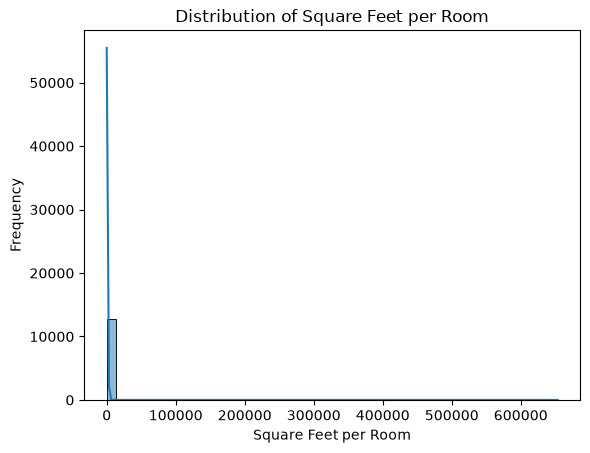

In [306]:
sns.histplot(df["sqft_per_room"], bins=50, kde=True)
plt.xlabel("Square Feet per Room")
plt.ylabel("Frequency")
plt.title("Distribution of Square Feet per Room")
plt.show()

In [307]:
df.sort_values("sqft_per_room").head(20)[
    ["room_count", "total_sqft", "sqft_per_room", "bath", "price", "location"]
]

,room_count,total_sqft,sqft_per_room,bath,price,location
4086,4.0,1.0000,0.250000,4.0,120.0,Sarjapur Road
4972,7.0,5.0000,0.714286,7.0,115.0,Srirampuram
349,3.0,11.0000,3.666667,3.0,74.0,Suragajakkanahalli
1122,5.0,24.0000,4.800000,2.0,150.0,Grihalakshmi Layout
1020,1.0,15.0000,15.000000,1.0,30.0,Weavers Colony
11558,4.0,60.0000,15.000000,4.0,218.0,Whitefield
5970,1.0,45.0000,45.000000,1.0,23.0,Mysore Road
12252,5.0,258.3336,51.666720,5.0,75.0,Gowdanapalya
4684,43.0,2400.0000,55.813953,40.0,660.0,Munnekollal
11559,18.0,1200.0000,66.666667,18.0,200.0,1Kasavanhalli


In [308]:
df.sort_values("sqft_per_room", ascending=False).head(20)[
    ["room_count", "total_sqft", "sqft_per_room", "bath", "price", "location"]
]

,room_count,total_sqft,sqft_per_room,bath,price,location
1086,2.0,1306800.00,653400.000000,2.0,29.5,Narasapura
1019,1.0,231303.60,231303.600000,1.0,110.0,Marathi Layout
7607,3.0,653400.00,217800.000000,3.0,217.0,Bommenahalli
648,9.0,1123031.25,124781.250000,9.0,265.0,Arekere
11615,3.0,261360.00,87120.000000,2.0,80.0,arudi
7334,1.0,87120.00,87120.000000,1.0,125.0,Kanakpura Road
7001,8.0,653400.00,81675.000000,6.0,290.0,Thyagaraja Nagar
7726,1.0,54885.60,54885.600000,1.0,125.0,Kanakpura Road
6333,2.0,91040.40,45520.200000,2.0,200.0,Harohalli
11320,1.0,41382.00,41382.000000,1.0,170.0,Arishinakunte


In [309]:
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]

In [310]:
print(df["price_per_sqft"].describe())

count    1.275300e+04
mean     8.028225e+03
std      1.085827e+05
min      2.257423e+00
25%      4.296875e+03
50%      5.485893e+03
75%      7.406306e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64


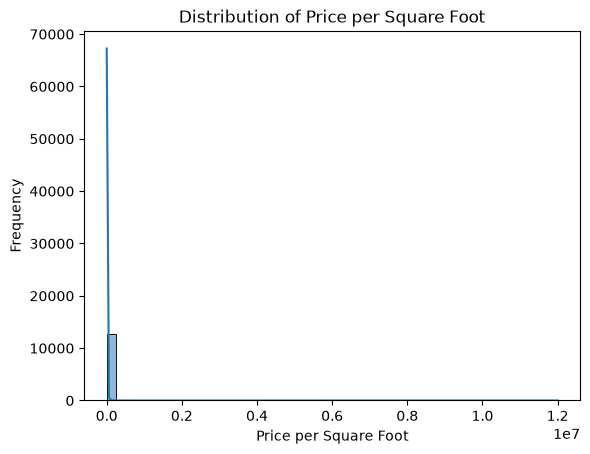

In [311]:
sns.histplot(df["price_per_sqft"], bins=50, kde=True)
plt.xlabel("Price per Square Foot")
plt.ylabel("Frequency")
plt.title("Distribution of Price per Square Foot")
plt.show()